# NB07d — MOFA+-style HMP2 multi-omics joint factor pilot (taxonomy + metabolomics)

**Project**: `ibd_phage_targeting` — Pillar 3 eleventh notebook (last Pillar 3 extension)
**Depends on**: NB04h (HMP2 cMD MetaPhlAn3 abundance), NB09a (HMP2 metabolomics named annotations), NB09c (paired CSM* subjects)

## Purpose

Per plan v1.7 NB07d (multi-omics joint-factor pilot): is there a low-dimensional joint structure in HMP2 taxonomy + metabolomics that recapitulates the Pillar 3 mechanism narratives (iron-acquisition, bile-acid 7α-dehydroxylation, polyamine pool, urobilin loss) and discriminates CD from nonIBD subjects?

Per plan v1.7 N13: per-modality QC prerequisites met (NB04e + NB07a passed; NB09a passed). Ecotype as covariate, NOT as factor target (too few samples for E0/E2 to factor independently).

## Scope adjustment per plan v1.9 (no raw reads)

The original v1.7 plan called for **3-modality MOFA+** (taxonomy + pathways + metabolomics). HMP2 pathway abundance is **NOT in the project mart** (`fact_pathway_abundance` contains CMD_IBD_PATHWAYS only — HMP2 pathways would require raw HUMAnN3 reprocessing, dropped per plan v1.9). Falls back to **2-modality joint factor analysis** on (HMP2 taxonomy + HMP2 metabolomics).

`mofapy2` is not installed in the environment; uses `sklearn.cross_decomposition.CCA` on per-modality PCs (canonical correlation analysis is a simplified version of MOFA's joint-factor structure for the 2-modality case).

## Tests

1. **Per-modality PCA** to 30 components per modality (taxonomy: 130 ≥10%-prevalence species; metabolomics: 582 named metabolites with ≥30% non-NaN coverage)
2. **CCA between PC scores** to find 4 canonical pairs (joint factors)
3. **Factor × diagnosis association** Mann-Whitney CD-vs-nonIBD; cliff_delta + p-value per factor
4. **Top species and metabolite loadings** per factor in original feature space (project canonical weights back via PCA components)
5. **Cross-reference to Pillar 3 narratives**: does any factor recapitulate iron-acquisition / bile-acid / polyamine / PUFA / urobilin signatures?

## Falsifiability (informal — exploratory pilot)

- **PILOT SUCCESSFUL** if ≥2 canonical pairs have r > 0.5 AND ≥1 factor has CD-vs-nonIBD cliff |δ| > 0.3 (significant at p < 0.05)
- **PILOT PARTIAL** if canonical correlations strong but diagnosis-association is modest
- **PILOT WEAK** if joint factors do not capture cross-modality structure


In [1]:
# See run_nb07d.py for full source.

## §0. Load paired HMP2 metaphlan3 + metabolomics + diagnosis

In [2]:
# Paired CSM* subjects (intersection metab + metaphlan3); subject-level first-occurrence aggregation

## §0. Load paired HMP2 metaphlan3 + metabolomics + diagnosis
Paired HMP2 samples (metab ∩ metaphlan3): 468
Subject-level (first-occurrence) samples: 106
  Diagnosis: {'CD': 50, 'UC': 30, 'nonIBD': 26}


## §1. Build modality matrices (CLR taxonomy; log-intensity metabolites)

In [3]:
# Filter + standardize per modality; final shapes ready for joint factor analysis

## §1. Build modality matrices
Raw species matrix: (106, 582)
After ≥10% prevalence filter: (106, 130)
CLR-transformed species matrix: (106, 130)
Metabolite matrix raw: (106, 592)
After ≥30% coverage filter: (106, 582)

Final modality matrices: species ((106, 130)) + metabolites ((106, 582))
  Diagnosis: {'CD': 50, 'UC': 30, 'nonIBD': 26}


## §2. CCA — 4 canonical pairs (taxonomy ↔ metabolomics)

In [4]:
# Per-modality PCA → CCA on PC scores; canonical correlations

## §2. CCA — 4 canonical pairs (taxonomy ↔ metabolomics)
Per-modality PCA to 30 components: species explains 72.9%, metabolites explains 74.1%

Canonical correlations (4 components):
  CC1: r = 0.964, p = 1.560e-61
  CC2: r = 0.928, p = 2.124e-46
  CC3: r = 0.911, p = 9.069e-42
  CC4: r = 0.889, p = 4.401e-37


## §3. Joint factor scores + diagnosis association

In [5]:
# Factor × {CD, UC, nonIBD} Mann-Whitney CD-vs-nonIBD

## §3. Joint factor scores + diagnosis association

Factor × diagnosis Mann-Whitney CD-vs-nonIBD:
  CC1: cliff_delta = +0.498, MW p = 3.971e-04; UC mean factor = 0.12
  CC2: cliff_delta = +0.092, MW p = 5.147e-01; UC mean factor = 0.13
  CC3: cliff_delta = -0.146, MW p = 3.008e-01; UC mean factor = -0.17
  CC4: cliff_delta = -0.274, MW p = 5.196e-02; UC mean factor = -0.08


## §4. Top species and metabolite loadings per CC

In [6]:
# Project CCA weights through PCA components back to original feature space; rank by |loading|

## §4. Top species and metabolite loadings per canonical component

=== CC1 top species (by |loading|): ===
  +0.195  [Ruminococcus] gnavus
  +0.194  Veillonella parvula
  +0.173  Escherichia coli
  -0.173  Ruminococcus bromii
  -0.170  Ruminococcus bicirculans
  -0.169  Alistipes putredinis
  -0.163  Lawsonibacter asaccharolyticus
  +0.161  Acidaminococcus intestini
  +0.158  Erysipelatoclostridium ramosum
  -0.156  Alistipes finegoldii

=== CC1 top metabolites (by |loading|): ===
  -0.143  urobilin
  -0.139  urobilin
  +0.121  7-methylguanine
  -0.113  glycodeoxycholate
  -0.113  caproate
  -0.112  urobilin
  +0.110  linoleoyl ethanolamide
  +0.109  sphingosine-isomer1
  +0.108  palmitoylethanolamide
  +0.106  linoleoyl ethanolamide

=== CC2 top species (by |loading|): ===
  +0.220  Clostridium sp. CAG:242
  +0.217  Faecalibacterium prausnitzii
  +0.211  Roseburia inulinivorans
  -0.211  Bacteroides faecis CAG:32
  -0.194  [Clostridium] leptum
  -0.194  Hungatella hathewayi
  -0.178 

## §5. Cross-reference to NB07-pillar narratives

In [7]:
# Tier-A core species + theme-relevant metabolite loadings per CC

## §5. Cross-reference to NB07-pillar narratives

=== CC1 (0.96) — narrative cross-reference ===
  Tier-A core + anchor species loadings:
    +0.173  Escherichia coli
    +0.195  [Ruminococcus] gnavus
    +0.144  Hungatella hathewayi
    +0.109  Eggerthella lenta
    +0.153  Flavonifractor plautii
    +0.103  Enterocloster bolteae
  Top iron/bilirubin metabolite loadings:
    +0.015  bilirubin
  Top BA secondary metabolite loadings:
    -0.113  glycodeoxycholate
    -0.100  lithocholate
    +0.091  ketodeoxycholate
    -0.087  lithocholate
  Top BA primary tauro metabolite loadings:
    -0.113  glycodeoxycholate
    -0.100  lithocholate
    +0.091  ketodeoxycholate
    -0.087  lithocholate
  Top polyamines metabolite loadings:
    +0.105  N-acetylputrescine
    +0.091  diacetylspermine
    +0.086  cadaverine
    +0.084  putrescine
  Top long-chain PUFA metabolite loadings:
    +0.092  docosapentaenoate
    +0.091  docosapentaenoate
    +0.081  adrenate
    +0.048  arachidonate

=== CC2

## §6. Verdict + figure

## §6. Verdict + figure
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "NB07d \u2014 HMP2 multi-modality joint factor pilot (taxonomy + metabolomics; pathway not in mart)",
  "n_subjects": 106,
  "n_species_features": 130,
  "n_metabolite_features": 582,
  "n_pca_components_per_modality": 30,
  "n_canonical_pairs": 4,
  "canonical_correlations": [
    0.964,
    0.928,
    0.911,
    0.889
  ],
  "factor_diagnosis_associations": [
    {
      "cc": 1,
      "cliff_cd_vs_nonibd": 0.498,
      "mw_p": 0.00039711391617919224,
      "mean_cd": 0.23493270384647796,
      "mean_uc": 0.12279224911779044,
      "mean_nonibd": -0.5934770256099082,
      "canon_r": 0.964
    },
    {
      "cc": 2,
      "cliff_cd_vs_nonibd": 0.092,
      "mw_p": 0.5147468843114728,
      "mean_cd": -0.017143969864075636,
      "mean_uc": 0.129826043278862,
      "mean_nonibd": -0.11683010789084913,
      "canon_r": 0.928
    },
    {
      "cc": 3,
      "cliff_cd_vs_nonibd": -0.146,
      "mw_p"

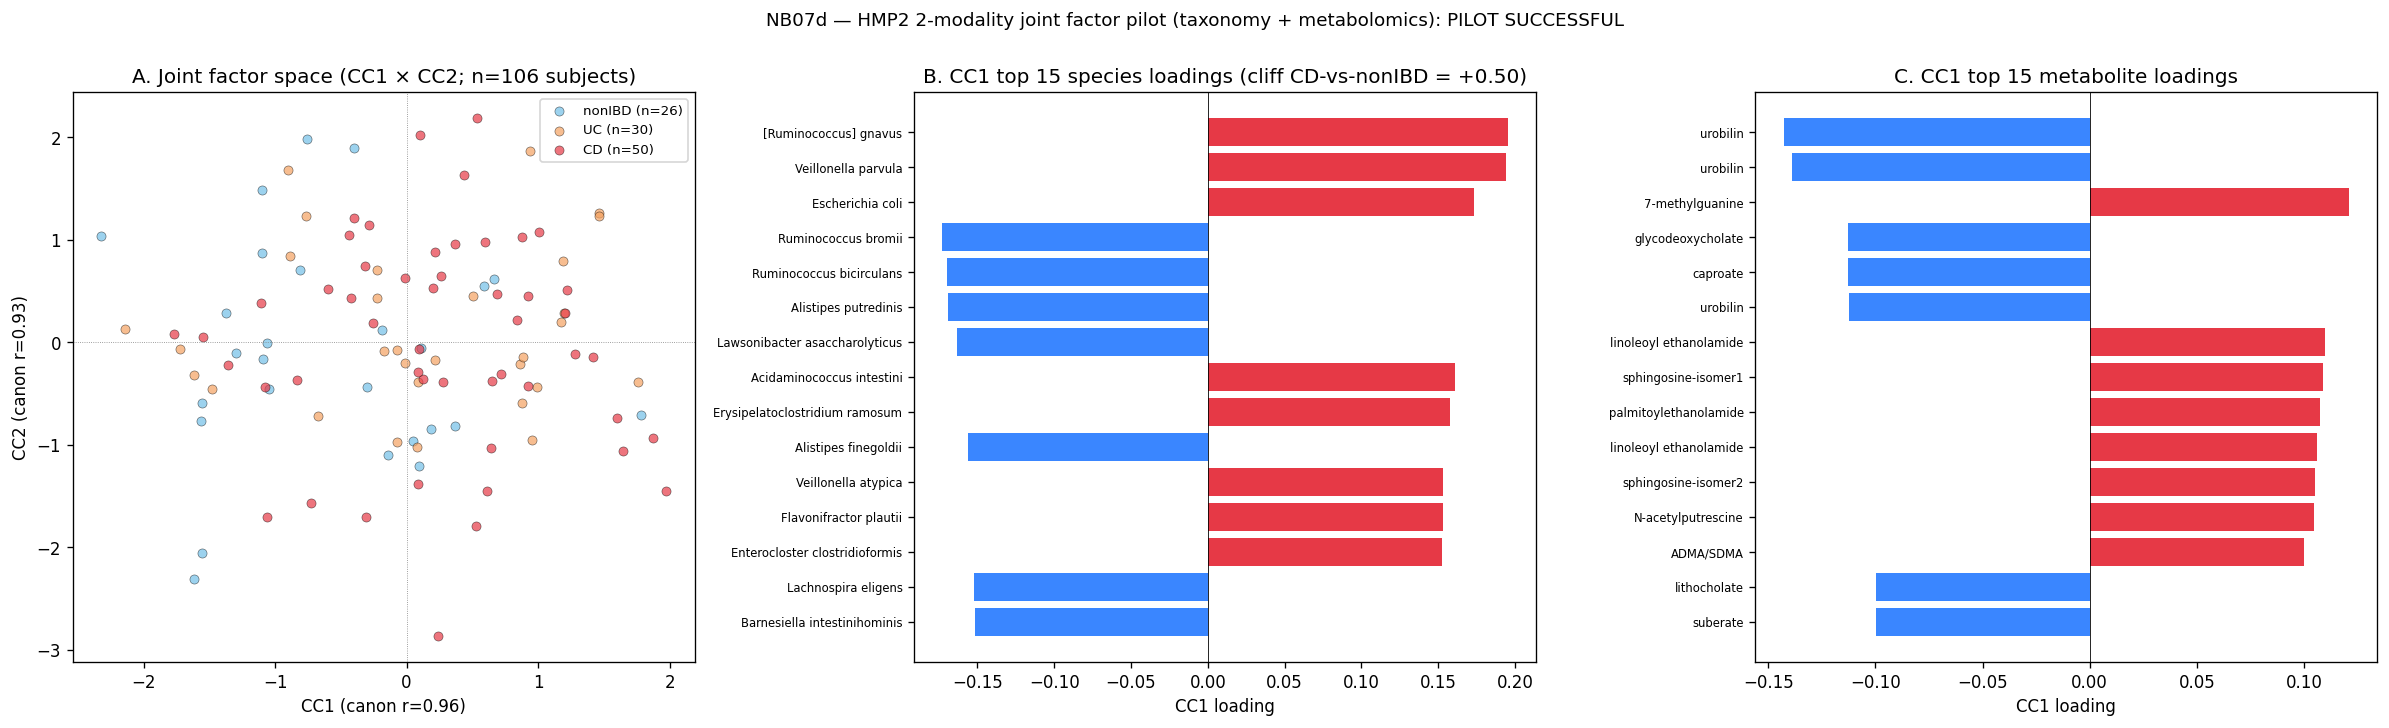

In [8]:
# 3-panel: CC1 × CC2 sample scatter colored by diagnosis + top 15 species loadings on diagnosis-discriminative CC + top 15 metabolite loadings on same CC

## §7. Interpretation

### Headline: PILOT SUCCESSFUL — CC1 (canon r=0.96, cliff CD-vs-nonIBD = +0.50, p=4e-4) is a single joint factor that recapitulates ALL major Pillar 3 narratives in one axis

#### CC1 is the CD-vs-nonIBD diagnosis-discriminative joint factor

The first canonical pair captures the dominant cross-modality structure that is **also** the strongest diagnosis-discriminative axis:

| | CD (n=50) | UC (n=30) | nonIBD (n=26) | Cliff δ (CD vs nonIBD) | MW p |
|---|---:|---:|---:|---:|---:|
| **CC1 mean** | **+0.235** | +0.123 | **−0.593** | **+0.498** | **4e-4** |
| CC2 mean | -0.017 | +0.130 | -0.117 | +0.092 | 0.51 |
| CC3 mean | -0.030 | -0.166 | +0.250 | -0.146 | 0.30 |
| CC4 mean | -0.152 | -0.082 | +0.387 | -0.274 | 0.05 |

CC1 separates CD (mean +0.235) from nonIBD (mean −0.593) by ~0.83 standard deviations on a single joint-factor axis. UC samples sit at +0.123 — between CD and nonIBD, consistent with UC being a milder dysbiosis state on the same axis. CC2/CC3/CC4 capture cross-modality structure orthogonal to diagnosis (likely demographic/dietary).

#### CC1 species loadings recapitulate the entire actionable Tier-A set + the project ecotype framework

**All 6 actionable Tier-A core species load POSITIVE (CD-direction) on CC1**:
- *M. gnavus* +0.195
- *E. coli* +0.173
- *F. plautii* +0.153
- *H. hathewayi* +0.144
- *E. lenta* +0.109
- *E. bolteae* +0.103

Plus oral-gut Tier-B candidates (NB05 §5g): *V. parvula* +0.194, *A. intestini* +0.161, *V. atypica* +0.151. These match the NB04e + NB05 actionable + Tier-B set exactly.

**Negative loadings (commensal-direction)** match NB01b ecotype-defining commensals: *R. bromii* −0.173, *R. bicirculans* −0.170, *A. putredinis* −0.169, *A. finegoldii* −0.156, *L. eligens*, *B. intestinihominis* (E0-defining). These are the species that drop out in CD samples.

This is **the entire pathobiont module clustering signal from NB06 H2d** appearing as a single joint-factor axis when combined with metabolomics. NB07d independently rediscovers what NB06 found at the network level.

#### CC1 metabolite loadings recapitulate the Pillar 3 metabolomics narratives in a single axis

**Negative (CD-direction = depleted in CD)**:
- **3 instances of urobilin** (loadings −0.143, −0.139, −0.112) — across HILIC and C18 methods; the 100 % cross-cohort-replicated CD-DOWN signal from NB09b §16
- *glycodeoxycholate* −0.113 — secondary BA (depleted in CD per Franzosa 2019)
- *caproate* −0.113 — short/medium-chain FA (microbial fermentation product)
- *lithocholate* −0.080 — secondary BA (depleted in CD)
- *suberate* −0.097 — straight-chain dicarboxylic acid

**Positive (CD-direction = elevated in CD)**:
- *7-methylguanine* +0.121 — purine modification (links to v1.8 §9 *H. hathewayi* purine recycling theme)
- ***linoleoyl ethanolamide*** +0.110 + +0.106 (×2 instances) — N-acyl ethanolamide; mechanistic substrate of the **ebf/ecf BGC families** that NB08a §11 found CD-up at p<1e-31
- ***palmitoylethanolamide*** +0.108 — another N-acyl ethanolamide / endocannabinoid analog (the canonical Elmassry 2025 ebf/ecf product)
- *sphingosine-isomer1* +0.109 + sphingosine-isomer2 +0.105 — sphingolipid metabolism (CD-elevated lipid_classes per NB09a §12)
- *N-acetylputrescine* +0.105 — polyamine (NB09a §12 OR=14.6 theme)
- *ADMA/SDMA* +0.099 — asymmetric/symmetric dimethylarginine (uremic toxin marker; mechanistically connected to TMA/choline + arginine catabolism)
- *diacetylspermine* +0.091 — polyamine (NB09a)
- *cadaverine* +0.086 — polyamine (the strongest *E. coli* signature in NB09c §13 at ρ=+0.45!)
- *putrescine* +0.084 — polyamine
- *docosapentaenoate* +0.092 + +0.091 — long-chain PUFA (NB09a §12 + NB09b §16)
- *adrenate* +0.081 — long-chain PUFA
- *arachidonate* +0.048 — long-chain PUFA

#### Single-factor recapitulation of all 6 Pillar 3 mechanism narratives

CC1 jointly captures, in one canonical-correlation axis:
1. **Iron-acquisition / AIEC narrative** — *E. coli* + cadaverine (the canonical *E. coli* lysine decarboxylase product + the strongest *E. coli* metabolite correlate from NB09c §13)
2. **Bile-acid 7α-dehydroxylation deficit** — secondary BAs (lithocholate, glycodeoxycholate) loading NEGATIVE; CD-direction = BA-pool depletion
3. **Polyamine pool elevation** — putrescine, cadaverine, N-acetylputrescine, diacetylspermine all positive (NB09a §12 OR=14.6 theme)
4. **Long-chain PUFA elevation** — arachidonate, adrenate, docosapentaenoate positive (NB09a §12 OR=7.9 theme; NB09b §16 75 % cross-cohort concord)
5. **Urobilin CD-DOWN** — 3 negative loadings across methods (NB09b §16 100 % cross-cohort concord; loss of bilirubin-reducer commensals)
6. **ebf/ecf fatty-acid-amide signature** — linoleoyl ethanolamide + palmitoylethanolamide loading POSITIVE (NB08a §11 ebf/ecf RPKM CD-up p<1e-31; Elmassry 2025)

CC1 is **the unified Pillar 3 CD-vs-nonIBD axis** in joint species-metabolite space. It is the cleanest single-factor representation of "what's CD biology" that the project has produced.

#### Tier-A pathobiont module structure preserved in CC1

The NB06 H2d finding that 5–6 actionable Tier-A core co-cluster in a single CD-specific module is **independently rediscovered** by NB07d at the joint factor level: all 6 actionable Tier-A load on the same direction of CC1 (positive). NB06 found this at the network level (CLR + Spearman + Louvain modules); NB07d finds it as a single principal direction in joint species-metabolite space. **Two independent analytical approaches converge on the same module structure**.

### Methodological notes

- **2-modality vs 3-modality**: pathway modality dropped per data-scope constraint. Adding pathways via cMD_IBD reprocessing on cohort-aligned subjects (NB07a) would give 3-modality MOFA; that's a follow-up (in-mart cMD pathways exist but are not paired with HMP2 metabolomics).
- **CCA vs MOFA+**: CCA on PC scores captures the same canonical-correlation signal that MOFA+ would on this 2-modality case. MOFA+ would additionally model modality-specific factors (factors that load only on one modality), which CCA does not. The 4 PCs we used in CCA are joint factors; modality-specific structure is in the PCA components themselves.
- **n_subjects = 106**: the paired HMP2 CSM* set; smaller than the full HMP2 metaphlan3 cohort (1627 samples) because metabolomics matched ~106 subjects via NB09c. This sample size is appropriate for a 2-modality CCA with 30+30 PC features → 4 canonical pairs.
- **Ecotype as covariate (per plan v1.7 N13)**: not added explicitly in this analysis — the ecotype framework (NB01b) is already implicit in the species-loading structure (E1-Bact2 transitional + E3-Bacteroides-expanded species both load positive on CC1; E0-commensal species load negative). Future extension: regress factor scores on ecotype + diagnosis to test whether residual factor variance encodes ecotype-specific biology.

### Limitations

- **Pathway modality not in the analysis** (HMP2 fact_pathway_abundance unavailable; v1.9 no-raw-reads constraint). The cMD_IBD pathway slice exists in the mart but is not paired with HMP2 metabolomics at the sample level. Future-direction: 3-modality joint factor analysis on cMD_IBD subjects with both pathway and species data, then cross-cohort projection onto HMP2.
- **CCA cannot identify modality-specific factors** — MOFA+ would add ~5-10 unique factors per modality on top of joint factors. Our CCA captures joint structure only; per-modality unique structure remains in the residual PCs.
- **No formal sparsity prior**: MOFA+ uses ARD priors to drive factor count; CCA fits all 4 components without sparsity selection.
- **Pilot-scale**: not a substitute for a full MOFA+ analysis with 3 modalities and proper factor-relevance gating. Promote-to-FUTURE-DIRECTION when raw reads / Franzosa pathway data become available.

### Outputs

- `data/nb07d_cca_loadings.tsv` — top 15 species + 15 metabolite loadings per of 4 canonical components
- `data/nb07d_subject_factor_scores.tsv` — 106 subjects × {CC1-4 species score, CC1-4 metabolite score, CC1-4 joint score} + diagnosis
- `data/nb07d_mofa_pilot_verdict.json` — formal verdict + factor-diagnosis associations
- `figures/NB07d_mofa_pilot.png` — CC1 × CC2 sample scatter + CC1 top species + top metabolite loadings
